
## NIO initial Points Density maps


In [25]:

# ============================================================
# Lorenz NIO Visual Discovery Paper
#
# Step 1 : Load NIO Results
# Step 2 : Summary Statistics
# Step 3 : 3D State Space Plot
# Step 4 : Projection Plots
# Step 5 : Sensitivity Density Maps
#
# Assumes:
#   nio_optimized_200_max.csv
#   nio_optimized_200_minimize.csv
#
# Uses:
#   900-step horizon only
#
# Ricardo Calix
# ============================================================


In [26]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.stats import gaussian_kde


In [27]:

# ============================================================
# CONFIGURATION
# ============================================================

MAX_FILE = "nio_optimized_200_max.csv"
MIN_FILE = "nio_optimized_200_minimize.csv"

HORIZON = 900


In [28]:

# ============================================================
# LOAD DATA
# ============================================================

max_df = pd.read_csv(MAX_FILE)
min_df = pd.read_csv(MIN_FILE)


In [29]:

max_df


,Time_steps,point_id,x0,y0,z0
0,300,0,16.151398,4.277729,22.093605
1,300,1,15.845501,1.823481,9.360580
2,300,2,-13.323767,-5.122620,24.481531
3,300,3,13.572533,5.495720,22.451601
4,300,4,4.694626,10.762936,37.049107
...,...,...,...,...,...
795,1300,195,5.102917,-23.309418,4.647880
796,1300,196,-2.239059,18.052277,34.899883
797,1300,197,0.967415,-10.967398,32.352410
798,1300,198,-10.688624,4.986160,48.020912


In [30]:

min_df


,Time_steps,point_id,x0,y0,z0
0,300,0,-4.968129,-3.096901,38.556705
1,300,1,19.760845,-17.344536,22.855420
2,300,2,6.272339,-9.626266,10.886422
3,300,3,11.664734,16.559116,11.334040
4,300,4,-18.035372,10.947620,11.471594
...,...,...,...,...,...
3995,1300,995,-1.737869,21.887096,17.248293
3996,1300,996,-18.381437,24.304570,34.046017
3997,1300,997,15.475384,-26.446705,7.493753
3998,1300,998,11.933991,-13.443027,43.715637


In [31]:

time_col = [c for c in max_df.columns if "time" in c.lower()][0]


In [32]:

time_col


'Time_steps'

In [33]:

max_data = max_df[max_df[time_col] == HORIZON].copy()
min_data = min_df[min_df[time_col] == HORIZON].copy()


In [34]:

max_data


,Time_steps,point_id,x0,y0,z0
400,900,0,14.820171,-25.260979,16.692131
401,900,1,15.720760,6.561710,28.394854
402,900,2,16.992207,17.115665,8.970388
403,900,3,7.872463,-16.584545,13.212249
404,900,4,12.512623,6.259079,24.815910
...,...,...,...,...,...
595,900,195,17.230614,26.919685,7.336345
596,900,196,4.402391,-0.364409,5.964898
597,900,197,-9.438676,15.676334,17.467579
598,900,198,15.544022,21.552284,42.456367


In [35]:

min_data


,Time_steps,point_id,x0,y0,z0
2000,900,0,4.966986,10.021538,31.511635
2001,900,1,-6.322627,-12.840626,37.320347
2002,900,2,7.394413,-28.341856,30.630493
2003,900,3,-12.411259,24.981144,7.780808
2004,900,4,7.244083,-22.632925,13.451992
...,...,...,...,...,...
2995,900,995,10.766609,-6.082588,43.135760
2996,900,996,5.685320,13.967495,8.769094
2997,900,997,13.899048,6.155747,25.138987
2998,900,998,5.291700,-22.350079,18.985342


In [36]:

print("\nLoaded Data")
print("----------------------------")
print("Max-sensitive points :", len(max_data))
print("Min-sensitive points :", len(min_data))



Loaded Data
----------------------------
Max-sensitive points : 200
Min-sensitive points : 1000




## SUMMARY STATISTICS


In [37]:

print("\n")
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)




SUMMARY STATISTICS


In [38]:

def summarize(df, label):

    stats = pd.DataFrame({
        "Mean": df[["x0","y0","z0"]].mean(),
        "Std":  df[["x0","y0","z0"]].std(),
        "Min":  df[["x0","y0","z0"]].min(),
        "Max":  df[["x0","y0","z0"]].max()
    })

    print("\n")
    print(label)
    print("-"*50)
    print(stats)


In [39]:

summarize(max_data, "MAX-SENSITIVE")




MAX-SENSITIVE
--------------------------------------------------
         Mean        Std        Min        Max
x0   1.279738  11.539555 -18.821892  19.647247
y0  -0.267779  17.654958 -27.928886  28.238873
z0  26.537101  13.773277   0.975020  48.410503


In [40]:

summarize(min_data, "MIN-SENSITIVE")




MIN-SENSITIVE
--------------------------------------------------
         Mean        Std        Min        Max
x0  -0.352005  10.710681 -19.615963  19.532303
y0   0.572764  16.509819 -29.212385  29.317139
z0  24.653248  14.191007   0.616188  49.371258




## 3D STATE SPACE


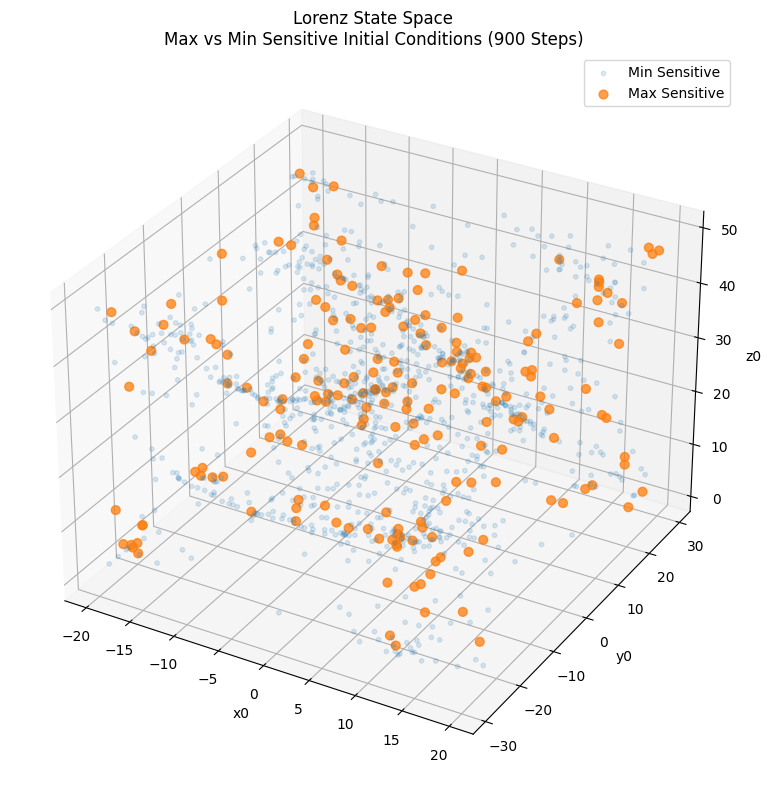

In [41]:

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)


ax.scatter(
    min_data["x0"],
    min_data["y0"],
    min_data["z0"],
    s=10,
    alpha=0.15,
    label="Min Sensitive"
)

ax.scatter(
    max_data["x0"],
    max_data["y0"],
    max_data["z0"],
    s=40,
    alpha=0.75,
    label="Max Sensitive"
)

ax.set_xlabel("x0")
ax.set_ylabel("y0")
ax.set_zlabel("z0")

ax.set_title(
    f"Lorenz State Space\nMax vs Min Sensitive Initial Conditions ({HORIZON} Steps)"
)

ax.legend()

plt.tight_layout()
plt.savefig(
    "Figure1_3D_StateSpace.png",
    dpi=300
)

plt.show()





## PROJECTION PLOTS


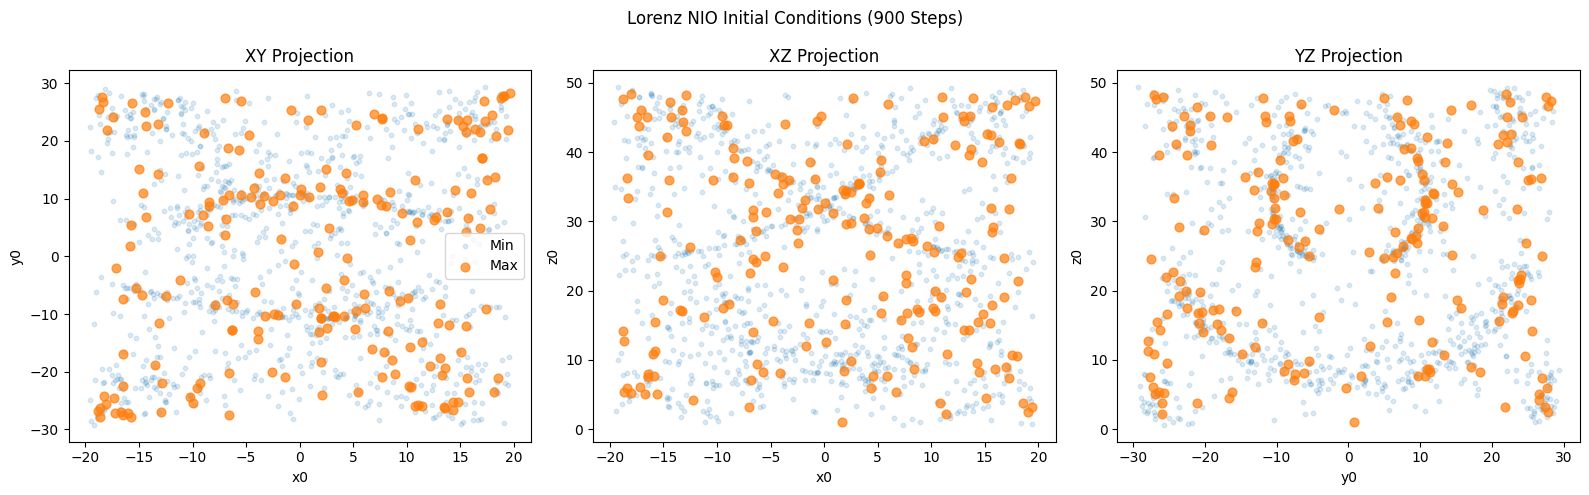

In [42]:


fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)


# ------------------------------------------------------------
# XY
# ------------------------------------------------------------

axs[0].scatter(
    min_data["x0"],
    min_data["y0"],
    s=10,
    alpha=0.15,
    label="Min"
)

axs[0].scatter(
    max_data["x0"],
    max_data["y0"],
    s=40,
    alpha=0.7,
    label="Max"
)

axs[0].set_title("XY Projection")
axs[0].set_xlabel("x0")
axs[0].set_ylabel("y0")

# ------------------------------------------------------------
# XZ
# ------------------------------------------------------------

axs[1].scatter(
    min_data["x0"],
    min_data["z0"],
    s=10,
    alpha=0.15
)

axs[1].scatter(
    max_data["x0"],
    max_data["z0"],
    s=40,
    alpha=0.7
)

axs[1].set_title("XZ Projection")
axs[1].set_xlabel("x0")
axs[1].set_ylabel("z0")

# ------------------------------------------------------------
# YZ
# ------------------------------------------------------------

axs[2].scatter(
    min_data["y0"],
    min_data["z0"],
    s=10,
    alpha=0.15
)

axs[2].scatter(
    max_data["y0"],
    max_data["z0"],
    s=40,
    alpha=0.7
)

axs[2].set_title("YZ Projection")
axs[2].set_xlabel("y0")
axs[2].set_ylabel("z0")


axs[0].legend()

plt.suptitle(
    f"Lorenz NIO Initial Conditions ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    "Figure2_ProjectionPlots.png",
    dpi=300
)

plt.show()




## SENSITIVITY DENSITY MAPS

* rho_max - rho_min



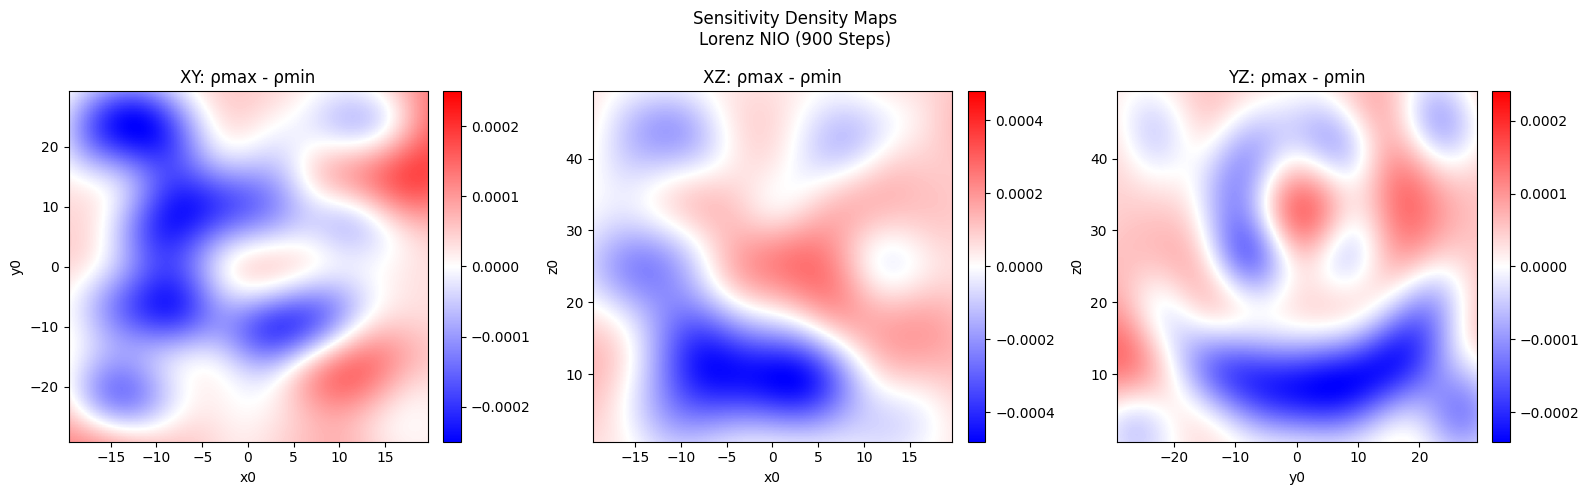

In [43]:

fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)

pairs = [
    ("x0","y0","XY"),
    ("x0","z0","XZ"),
    ("y0","z0","YZ")
]


for ax, (a,b,title) in zip(axs,pairs):

    all_a = np.concatenate([
        max_data[a],
        min_data[a]
    ])

    all_b = np.concatenate([
        max_data[b],
        min_data[b]
    ])

    grid_a = np.linspace(
        all_a.min(),
        all_a.max(),
        120
    )

    grid_b = np.linspace(
        all_b.min(),
        all_b.max(),
        120
    )

    A,B = np.meshgrid(
        grid_a,
        grid_b
    )

    kde_max = gaussian_kde(
        np.vstack([
            max_data[a],
            max_data[b]
        ])
    )

    kde_min = gaussian_kde(
        np.vstack([
            min_data[a],
            min_data[b]
        ])
    )

    rho_max = kde_max(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    rho_min = kde_min(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    density_difference = (
        rho_max - rho_min
    )

    vmax = np.abs(
        density_difference
    ).max()

    image = ax.imshow(
        density_difference,
        origin="lower",
        extent=[
            grid_a.min(),
            grid_a.max(),
            grid_b.min(),
            grid_b.max()
        ],
        aspect="auto",
        cmap="bwr",
        vmin=-vmax,
        vmax=vmax
    )

    ax.set_title(
        f"{title}: ρmax - ρmin"
    )

    ax.set_xlabel(a)
    ax.set_ylabel(b)

    plt.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

 
plt.suptitle(
    f"Sensitivity Density Maps\nLorenz NIO ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    "Figure3_DensityMaps.png",
    dpi=300
)

plt.show()

